# EDA - SmartDoc

- Dataset: `smart_doc_extracted` (~24,860 images)
- Labels: `gt_corners.csv` - normalized [0, 1] corner coords (x1,y1 ~ x4,y4), order TL, TR, BR, BL
- CSV: `data/smartdoc/gt_corners.csv`

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
from src.data.dataset import Dataset
from src.data.transforms import Denormalize
from src.core.factory import get_transform, get_samples, IMAGENET_MEAN, IMAGENET_STD
from src.utils.plot import show_samples

In [4]:
CSV_PATH = os.path.join(PROJECT_ROOT, "data/smartdoc/gt_corners.csv")
INPUT_SIZE = 512

## 1. Dataset 로드 및 기본 검증

In [5]:
dataset = Dataset(CSV_PATH)

print(f"Total samples : {len(dataset)}")

image, corners = dataset[0]
print(f"Image shape   : {tuple(image.shape)}  dtype={image.dtype}")
print(f"Corners shape : {tuple(corners.shape)}  dtype={corners.dtype}")
print(f"Corners       : {corners.numpy().round(4)}")

Total samples : 24860
Image shape   : (3, 1080, 1920)  dtype=torch.float32
Corners shape : (4, 2)  dtype=torch.float32
Corners       : [[0.3636 0.1856]
 [0.6136 0.1773]
 [0.6527 0.8052]
 [0.3605 0.8251]]


## 2. Train / Test split

In [6]:
train_set, test_set = dataset.split(split_ratio=0.8, seed=42)

print(f"Train : {len(train_set)}")
print(f"Test  : {len(test_set)}")

# 동일 seed로 재생성 시 인덱스 일치 확인
train2, _ = dataset.split(split_ratio=0.8, seed=42)
print(f"Seed 42 재생성 일치: {set(train_set.indices) == set(train2.indices)}")

Train : 19888
Test  : 4972
Seed 42 재생성 일치: True


## 3. 샘플 시각화

In [ ]:
def to_images_and_corners(subset, num_samples):
    images, corners_list = [], []
    for index in subset.indices[:num_samples]:
        image_path, corners = subset.dataset.samples[index]
        images.append(Image.open(image_path).convert("RGB"))
        corners_list.append(corners)
    return images, corners_list

corner_labels = ["TL", "TR", "BR", "BL"]

sample_images, sample_corners = to_images_and_corners(train_set, num_samples=16)
show_samples(sample_images, sample_corners, title="SmartDoc - Train samples (first 8)", labels=corner_labels)

In [ ]:
sample_images, sample_corners = to_images_and_corners(test_set, num_samples=16)
show_samples(sample_images, sample_corners, title="SmartDoc - Test samples (first 8)", labels=corner_labels)

## 4. 코너 좌표 분포

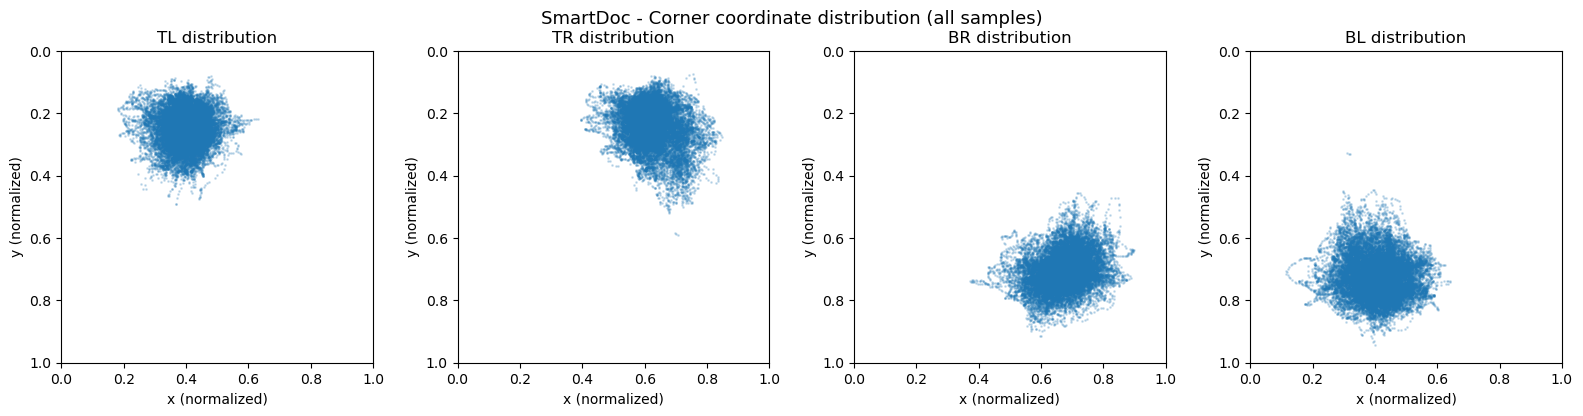

In [10]:
# dataset.samples에서 직접 읽어 이미지 로드 없이 수집
all_corners = np.stack([corners for _, corners in dataset.samples])  # (N, 4, 2)
pts = all_corners.reshape(-1, 4, 2)  # (N, 4, 2)

corner_labels = ["TL", "TR", "BR", "BL"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.scatter(pts[:, i, 0], pts[:, i, 1], s=1, alpha=0.2)
    ax.set_title(f"{corner_labels[i]} distribution")
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)
    ax.set_xlabel("x (normalized)")
    ax.set_ylabel("y (normalized)")
    ax.set_aspect("equal")
fig.suptitle("SmartDoc - Corner coordinate distribution (all samples)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Transform 적용 확인

In [11]:
transform = get_transform(split="train", input_size=INPUT_SIZE)
dataset_t = Dataset(CSV_PATH, transform=transform)
image_t, corners_t = dataset_t[0]

print(f"Tensor shape    : {tuple(image_t.shape)}   dtype={image_t.dtype}")
print(f"Corners shape   : {tuple(corners_t.shape)}  dtype={corners_t.dtype}")
print(f"Corners min/max : {corners_t.min():.4f} / {corners_t.max():.4f}")
print(f"Pixel min/max   : {image_t.min():.4f} / {image_t.max():.4f}")

Tensor shape    : (3, 512, 512)   dtype=torch.float32
Corners shape   : (4, 2)  dtype=torch.float32
Corners min/max : 0.1818 / 0.8259
Pixel min/max   : -1.8439 / 2.4308


## 6. get_samples 확인

In [12]:
train_images, train_corners = get_samples("train", CSV_PATH, INPUT_SIZE, num_samples=20)
test_images, test_corners = get_samples("test", CSV_PATH, INPUT_SIZE, num_samples=20)

print(f"train_images  : {tuple(train_images.shape)}  dtype={train_images.dtype}")
print(f"train_corners : {tuple(train_corners.shape)}  dtype={train_corners.dtype}")
print(f"test_images   : {tuple(test_images.shape)}  dtype={test_images.dtype}")
print(f"test_corners  : {tuple(test_corners.shape)}  dtype={test_corners.dtype}")

train_images  : (20, 3, 512, 512)  dtype=torch.float32
train_corners : (20, 4, 2)  dtype=torch.float32
test_images   : (20, 3, 512, 512)  dtype=torch.float32
test_corners  : (20, 4, 2)  dtype=torch.float32


In [ ]:
denormalize = Denormalize(IMAGENET_MEAN, IMAGENET_STD)

def to_batch_images_and_corners(images, corners):
    denorm_images, corners_list = [], []
    for image, corner in zip(images, corners):
        denorm_image, _ = denormalize(image, corner)
        denorm_images.append(denorm_image.clamp(0.0, 1.0).permute(1, 2, 0).numpy())
        corners_list.append(corner.numpy())
    return denorm_images, corners_list

batch_images, batch_corners = to_batch_images_and_corners(train_images, train_corners)
show_samples(batch_images, batch_corners, title="SmartDoc - get_samples(train, num_samples=20)")

In [ ]:
batch_images, batch_corners = to_batch_images_and_corners(test_images, test_corners)
show_samples(batch_images, batch_corners, title="SmartDoc - get_samples(test, num_samples=20)")